In [2]:
import scanpy as sc
import anndata as ad

In [3]:
adata = sc.read_h5ad('../../certpro-data/final-objects/final-bmmc-raw.h5ad')

In [4]:
sc.pp.calculate_qc_metrics(adata)

(                                  n_genes_by_counts  log1p_n_genes_by_counts  \
 barcodes                                                                       
 97396d7e733f11ee811062d5ef28e4ea               2295                 7.738924   
 97397620733f11ee811062d5ef28e4ea               2947                 7.988882   
 97397850733f11ee811062d5ef28e4ea               4623                 8.439015   
 97397972733f11ee811062d5ef28e4ea               1791                 7.491088   
 9739820a733f11ee811062d5ef28e4ea               3112                 8.043342   
 ...                                             ...                      ...   
 50907fa27db111efbb201a1ce35e11c5               3205                 8.072779   
 50909fe67db111efbb201a1ce35e11c5               2034                 7.618251   
 5090b5947db111efbb201a1ce35e11c5               3265                 8.091321   
 5090b95e7db111efbb201a1ce35e11c5               1579                 7.365180   
 5090d3c67db111efbb201a1ce35

In [5]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [6]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.25)

In [7]:
sc.pp.scale(adata, max_value=10, zero_center=False)

In [8]:
sc.pp.pca(adata, svd_solver="arpack")

In [9]:
%%time
sc.pp.neighbors(adata, n_neighbors=50, use_rep="X_pca", n_pcs=20)

CPU times: user 10min 54s, sys: 19.9 s, total: 11min 14s
Wall time: 11min 22s


In [10]:
%%time
sc.tl.umap(adata, min_dist=0.45, random_state=0, n_components=2)

CPU times: user 44min 3s, sys: 9.29 s, total: 44min 13s
Wall time: 32min 8s


In [11]:
%%time
sc.tl.leiden(adata, resolution=1, n_iterations=2)

<timed eval>:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.


CPU times: user 9min 10s, sys: 18.8 s, total: 9min 29s
Wall time: 9min 23s


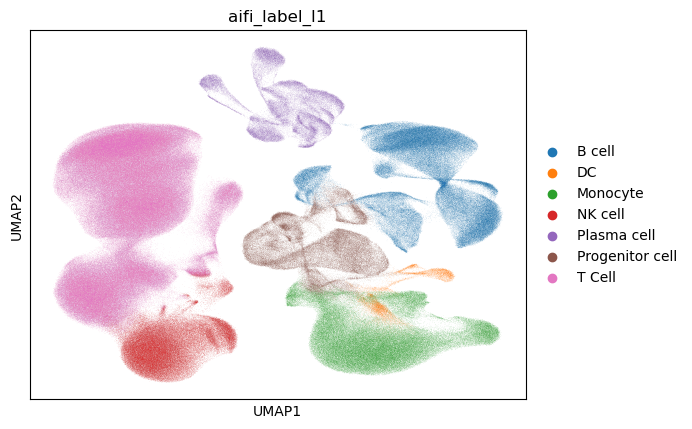

In [12]:
sc.pl.umap(adata, color = 'aifi_label_l1')

In [13]:
adata

AnnData object with n_obs × n_vars = 1171965 × 33538
    obs: 'adt_qc_flag', 'adt_umis', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'ext_l1', 'ext_l2', 'ext_l3', 'healthy_l1', 'healthy_l2', 'healthy_l3', 'aifi_l1', 'aifi_l2', 'aifi_l3', 'predicted_doublet', 'doublet_score', 'sample.sampleKitGuid', 'sample.visitDetails', 'sample.visitName', 'sample.drawDate', 'sample.daysSinceFirstVisit', 'sample.diseaseStatesRecordedAtVisit', 'subject.biologicalSex', 'subject.birthYear', 'subject.ethnicity', 'subject.partnerCode', 'subject.race', 'subject.subjectGuid', 'specimen.specimenGuid', 'cohort.cohortGuid', 'manual.time_stamp', 'tissue', 'manual.response', 'manual.response_type', 'manual.extracted_name', 'manual.batch_id', 'manual.category', 'manual.treatment_dara', 'manual.flu_response',

In [14]:
adata.write('save_normal_results.h5ad')